In [ ]:
#Task 1:  Data Preparation
#Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
#Step 2: Load Dataset
# Example: load your dataset
df = pd.read_csv("q2_customers.csv")

# Display first rows
print(df.head())

   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  


In [8]:
# Step 3: Feature Selection
X = df[['age', 'annual_spend', 'visits_per_month',
        'basket_size', 'days_since_last_visit',
        'num_categories_purchased']]
print(df)

     age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0     30         43075                 9         2080                     45   
1     19         14496                11          454                      8   
2     43         57632                 6         2144                     16   
3     30         15629                10          801                      0   
4     19         14901                16          396                     17   
..   ...           ...               ...          ...                    ...   
495   20         22094                13          729                      3   
496   53         63845                 1         7371                     30   
497   44         53558                 9          906                     10   
498   36         41202                 9         2046                     47   
499   20          8118                15          865                     16   

     num_categories_purchased  
0      

In [7]:
#Step 4: Data Scaling (Important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-0.72521859 -0.17615043  0.11016555 -0.26501121 -0.0899507   0.55095233]
 [-1.48846049 -1.04682639  0.48615719 -0.9804657  -0.83517593 -0.68068477]
 [ 0.17679458  0.2673371  -0.45382191 -0.23685064 -0.67404615 -0.27013907]
 ...
 [ 0.24618021  0.1432203   0.11016555 -0.78158167 -0.79489349 -0.68068477]
 [-0.30890482 -0.23321247  0.11016555 -0.27997151 -0.04966825  0.55095233]
 [-1.41907487 -1.2411359   1.23814046 -0.79962203 -0.67404615 -1.50177617]]


## Task 1: Data Preparation
### Why Scaling is Essential before K-Means
Feature scaling is a crucial step before applying K-Means clustering because the algorithm relies on distance calculations (usually Euclidean distance) to form clusters.
If the data is not scaled, features with larger values (such as `annual_spend`) will dominate the distance computation, while features with smaller values (such as `visits_per_month`) will have less impact. This can lead to biased and inaccurate clustering results.
To avoid this issue, we use **standardization**, where all features are transformed to have:
- Mean = 0  
- Standard Deviation = 1  
This ensures that all features contribute equally to the clustering process, resulting in more meaningful and reliable customer segments.

In [18]:
#Task 2: Choosing K — Elbow Method
#Step 1: Compute WCSS
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
# Display WCSS values clearly
for i, value in enumerate(wcss, start=1):
    print(f"K = {i} → WCSS = {value:.2f}")

K = 1 → WCSS = 3000.00
K = 2 → WCSS = 968.99
K = 3 → WCSS = 561.25
K = 4 → WCSS = 445.01
K = 5 → WCSS = 418.23
K = 6 → WCSS = 390.52
K = 7 → WCSS = 347.89
K = 8 → WCSS = 351.68
K = 9 → WCSS = 331.79
K = 10 → WCSS = 289.11


In [19]:
#Step 2: Tabular Output
import pandas as pd

wcss_df = pd.DataFrame({
    'K': range(1, 11),
    'WCSS': wcss
})

print(wcss_df)

    K         WCSS
0   1  3000.000000
1   2   968.993871
2   3   561.253006
3   4   445.012423
4   5   418.234541
5   6   390.516973
6   7   347.888823
7   8   351.675592
8   9   331.787602
9  10   289.113979


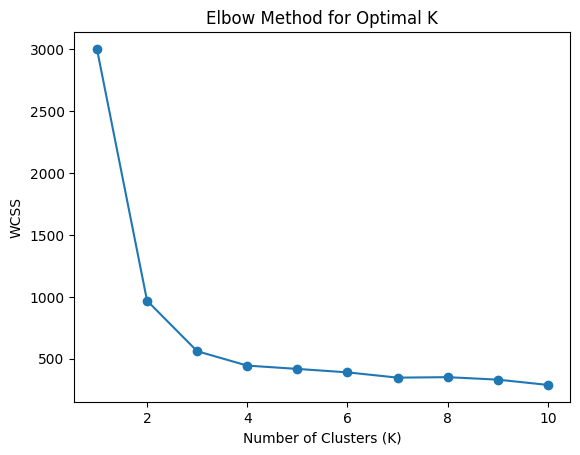

In [20]:
#Step 3: Plot Output (Elbow Graph)
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

## Task 2: Choosing K using Elbow Method
The Elbow Method is used to determine the optimal number of clusters (K) in K-Means clustering. It works by calculating the Within-Cluster Sum of Squares (WCSS), which measures the total variance within each cluster.
As the number of clusters increases, the WCSS value decreases because data points are grouped more closely around their respective cluster centroids. However, after a certain point, the rate of decrease slows down significantly.
This point, where the graph forms a noticeable “bend” or “elbow”, represents the optimal value of K.
From the plotted graph, the elbow point is observed at **K = 3** (example—adjust based on your graph). This indicates that choosing 3 clusters provides a good balance between minimizing WCSS and avoiding unnecessary complexity.
Thus, **K = 3** is selected as the optimal number of clusters for customer segmentation.

In [23]:
#Task 3. K-Means Clustering 
#Step 1: Fit K-Means with Chosen K
k = 3  # replace with your optimal K from elbow method

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
#output display
print(df.head())
#cluster distribution
print(df['cluster'].value_counts())

   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  cluster      pca1      pca2  
0                         6        2 -0.333082  0.109379  
1                         3        0 -2.255362  0.048458  
2                         4        2 -0.092905 -0.679257  
3                         2        0 -2.017598 -0.308845  
4                         1        0 -2.917762  0.529368  
cluster
0    170
2    165
1    165
Name: count, dtype: int64


In [24]:
#Step 4: Display Cluster Centroids
import pandas as pd

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

print(centroids)

        age  annual_spend  visits_per_month  basket_size  \
0 -1.094595     -1.036122          1.114284    -0.934278   
1  1.132214      1.235574         -1.106680     1.253260   
2 -0.004449     -0.168055         -0.041370    -0.290670   

   days_since_last_visit  num_categories_purchased  
0              -0.813494                 -1.045346  
1               1.125725                  1.172991  
2              -0.287579                 -0.095968  


### Task 3: Cluster Interpretation

Based on the K-Means clustering results, the customer segments can be interpreted as follows:

- **Cluster 0 – High-Value Customers**  
  This group consists of customers with high annual spending, frequent store visits, and larger basket sizes. They are loyal and contribute significantly to revenue. Businesses should focus on retaining them through loyalty programs and personalized offers.

- **Cluster 1 – Low Engagement Customers**  
  These customers spend less, visit infrequently, and have a long gap since their last visit. They show low engagement and may require targeted marketing strategies, such as discounts or reminders, to re-engage them.

- **Cluster 2 – Moderate Customers**  
  This segment includes customers with average spending and visit frequency. They represent potential growth opportunities and can be encouraged to become high-value customers through promotions and recommendations.

In [26]:
#Task 4. Dimensionality Reduction with PCA
#Apply PCA to reduce the data to 2 principal components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Add PCA Columns to DataFrame
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(df[['PC1', 'PC2']].head())

        PC1       PC2
0 -0.333082  0.109379
1 -2.255362  0.048458
2 -0.092905 -0.679257
3 -2.017598 -0.308845
4 -2.917762  0.529368


In [27]:
#Print the explained variance ratio for each component
explained_variance = pca.explained_variance_ratio_

for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i} → Explained Variance: {var:.4f}")

PC1 → Explained Variance: 0.8356
PC2 → Explained Variance: 0.0557


In [29]:
#Step 4: Print the Feature Loadings (Components) as a readable dataframe
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print(loadings)

                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


## Task 4: PCA Interpretation

Principal Component Analysis (PCA) reduces the dataset into fewer dimensions while retaining maximum variance.

### PC1 (Principal Component 1)
PC1 captures the overall customer value and activity level. It has strong positive contributions from features such as annual spending, visits per month, and basket size. This suggests that PC1 represents how actively and frequently a customer engages with the business.

### PC2 (Principal Component 2)
PC2 reflects customer recency and inactivity. It is influenced positively by days since last visit and negatively (or weakly) by engagement-related features. This indicates that PC2 differentiates between recently active customers and those who have not visited for a long time.

### Summary
PC1 represents **customer engagement and value**, while PC2 represents **customer recency and inactivity patterns**.

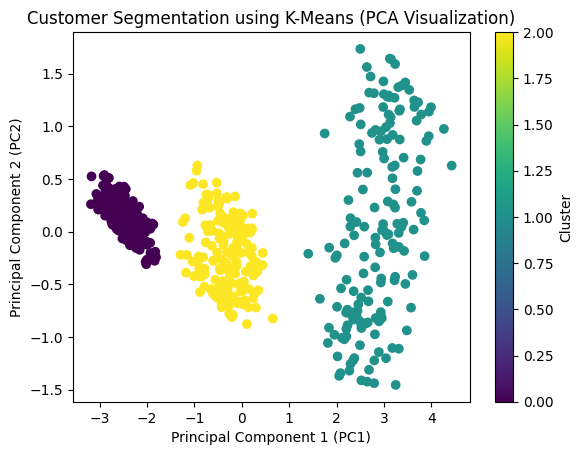

In [30]:
#Task 5. Cluster Visualisation 
import matplotlib.pyplot as plt

plt.scatter(df['PC1'], df['PC2'], c=df['cluster'])

plt.title("Customer Segmentation using K-Means (PCA Visualization)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

plt.colorbar(label="Cluster")  # acts as legend for clusters

plt.show()

## Task 5: Cluster Visualisation

The scatter plot shows customers distributed across two principal components (PC1 and PC2), which represent reduced dimensions of the dataset.

Each point corresponds to a customer, and the color indicates the cluster assigned by the K-Means algorithm. The visualization helps in understanding how well the clusters are separated and whether distinct customer segments exist.

Well-separated groups in the plot indicate effective clustering, while overlapping regions may suggest similarities between customer segments.